In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
from sklearn.metrics import r2_score, mean_squared_error

In [3]:
df = pd.read_csv("saved_files/df_boyas_tiffs_c2x_test.csv")

In [6]:
df.head(2)

,Date,Buoy,Latitude,Longitude,Band_1,Band_2,Band_3,Band_4,Band_5,Band_6,Band_7,Chl
0,2018-08-29,CTD1,4.187246e+06,695024.711677,0.010484,0.014709,0.023659,0.007710,0.005686,0.001559,0.0,0.505301
1,2018-08-29,CTD2,4.181518e+06,693105.156141,0.010867,0.015820,0.020610,0.004781,0.003242,0.000838,0.0,0.589946


In [7]:
df = df.drop(columns=["Latitude", "Longitude"])
df = df.rename(columns={"Band_1" : "UltraBlue", "Band_2" : "Blue", "Band_3" : "Green", "Band_4" : "Red", "Band_5" : "NIR1", "Band_6" : "NIR2", "Band_7" : "NIR3"})
df['Date'] = pd.to_datetime(df['Date'])
dates = df["Date"].copy()
df = df.drop(columns=["Date"]) 
# df = df.drop(columns=["Latitude", "Longitude", "Band_8", "Band_9", "Band_10", "Band_11", "Band_12", "Band_13"])
# df = df.rename(columns={"Band_1" : "UltraBlue", "Band_2" : "Blue", "Band_3" : "Green", "Band_4" : "Red", "Band_5" : "NIR1", "Band_6" : "NIR2", "Band_7" : "NIR3"})
# df['Date'] = pd.to_datetime(df['Date'])
# dates = df["Date"].copy()
# df = df.drop(columns=["Date"]) #df.drop(columns=["Date","Buoy"])
# #df.loc[:, ['UltraBlue', 'Blue', 'Green', 'Red', 'NIR1', 'NIR2', 'NIR3']] += 1

In [13]:
df.describe()

,UltraBlue,Blue,Green,Red,NIR1,NIR2,NIR3,Chl,norm_dif_green_blue,index_green_blue,norm_dif_green_red,index_green_red
count,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,2.000000e+01,20.000000,20.000000,20.000000,20.000000,20.000000
mean,0.010665,0.015286,0.020592,0.005411,0.003758,0.000979,-8.610000e-43,0.900069,0.149724,1.329474,0.595964,11.687858
std,0.002838,0.004098,0.005378,0.002241,0.001543,0.000394,1.349366e-42,0.302478,0.044884,0.290626,0.081315,5.030487
min,0.005009,0.007162,0.011346,0.002210,0.001546,0.000420,-2.870000e-42,0.424637,0.071055,0.895053,0.474188,6.077142
25%,0.009236,0.013101,0.017707,0.003537,0.002374,0.000597,-2.870000e-42,0.647313,0.127320,1.169412,0.538335,8.250468
50%,0.010901,0.015750,0.020431,0.005429,0.003831,0.000967,0.000000e+00,0.857799,0.141701,1.252113,0.585213,10.304474
75%,0.011665,0.017328,0.023486,0.007005,0.004878,0.001273,0.000000e+00,1.151183,0.171026,1.441237,0.637502,13.244507
max,0.018251,0.026186,0.034691,0.009961,0.006288,0.001559,0.000000e+00,1.395563,0.233276,1.934572,0.773450,25.189229


In [8]:
df.head(3)

,Buoy,UltraBlue,Blue,Green,Red,NIR1,NIR2,NIR3,Chl
0,CTD1,0.010484,0.014709,0.023659,0.007710,0.005686,0.001559,0.0,0.505301
1,CTD2,0.010867,0.015820,0.020610,0.004781,0.003242,0.000838,0.0,0.589946
2,CTD3,0.010168,0.014797,0.018205,0.004399,0.002975,0.000760,0.0,0.666435


### 1. De "Análisis multisensor de la variabilidad espacio temporal de diversos parámetros biofísicos en el Mar Menor"

La fórmula que se propone en este artículo es $y = 0.6386 e^{4.7513x}$, donde $y$ es la clorofila y $x$ es la relación de $(Green - Blue)/(Green + Blue)$

In [9]:
def norm_dif(band1, band2):
    index = (band1 - band2)/(band1 + band2 + 1e-8)
    return index

def add_index_green_blue(data):
    df["norm_dif_green_blue"] = norm_dif(data["Green"], data["Blue"])
    df[f"index_green_blue"] = 0.6386*np.exp(4.7513*(norm_dif(data["Green"], data["Blue"])))
add_index_green_blue(df)

def add_index_green_red(data):
    df["norm_dif_green_red"] = norm_dif(data["Green"], data["Red"])
    df[f"index_green_red"] = 0.6386*np.exp(4.7513*(norm_dif(data["Green"], data["Red"])))
add_index_green_red(df)

In [166]:
df = df.loc[df["Chl"]>0.5]

In [10]:
r2 = r2_score(df["Chl"], df["index_green_blue"])
print('R squared GreenBlue: %.3f' % r2)
r2 = r2_score(df["Chl"], df["index_green_red"])
print('R squared GreenRed: %.3f' % r2)

R squared GreenBlue: -3.648
R squared GreenRed: -1618.944


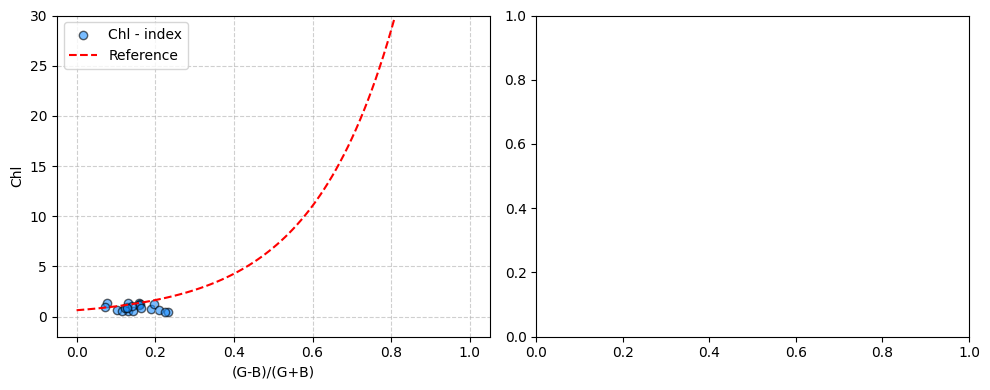

In [11]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))

# Train plot
axes[0].scatter(df["norm_dif_green_blue"], df["Chl"], color="dodgerblue", alpha=0.6, edgecolor="k", label="Chl - index")
axes[0].plot(np.linspace(0,1, 101), 0.6386*np.exp(4.7513*(np.linspace(0,1, 101))), color="red", linestyle="--", label="Reference")
axes[0].set_xlabel("(G-B)/(G+B)")
axes[0].set_ylabel("Chl")
axes[0].legend()
axes[0].grid(True, linestyle="--", alpha=0.6)
axes[0].set_ylim(-2,30)

# Test plot
# axes[1].scatter(y_test, test_prediction, color="orange", alpha=0.6, edgecolor="k", label="Test prediction")
# axes[1].plot(y_test, y_test, color="red", linestyle="--", label="Reference")
# axes[1].set_xlabel("Observed Chl")
# axes[1].set_ylabel("Predicted Chl")
# axes[1].legend()
# axes[1].grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

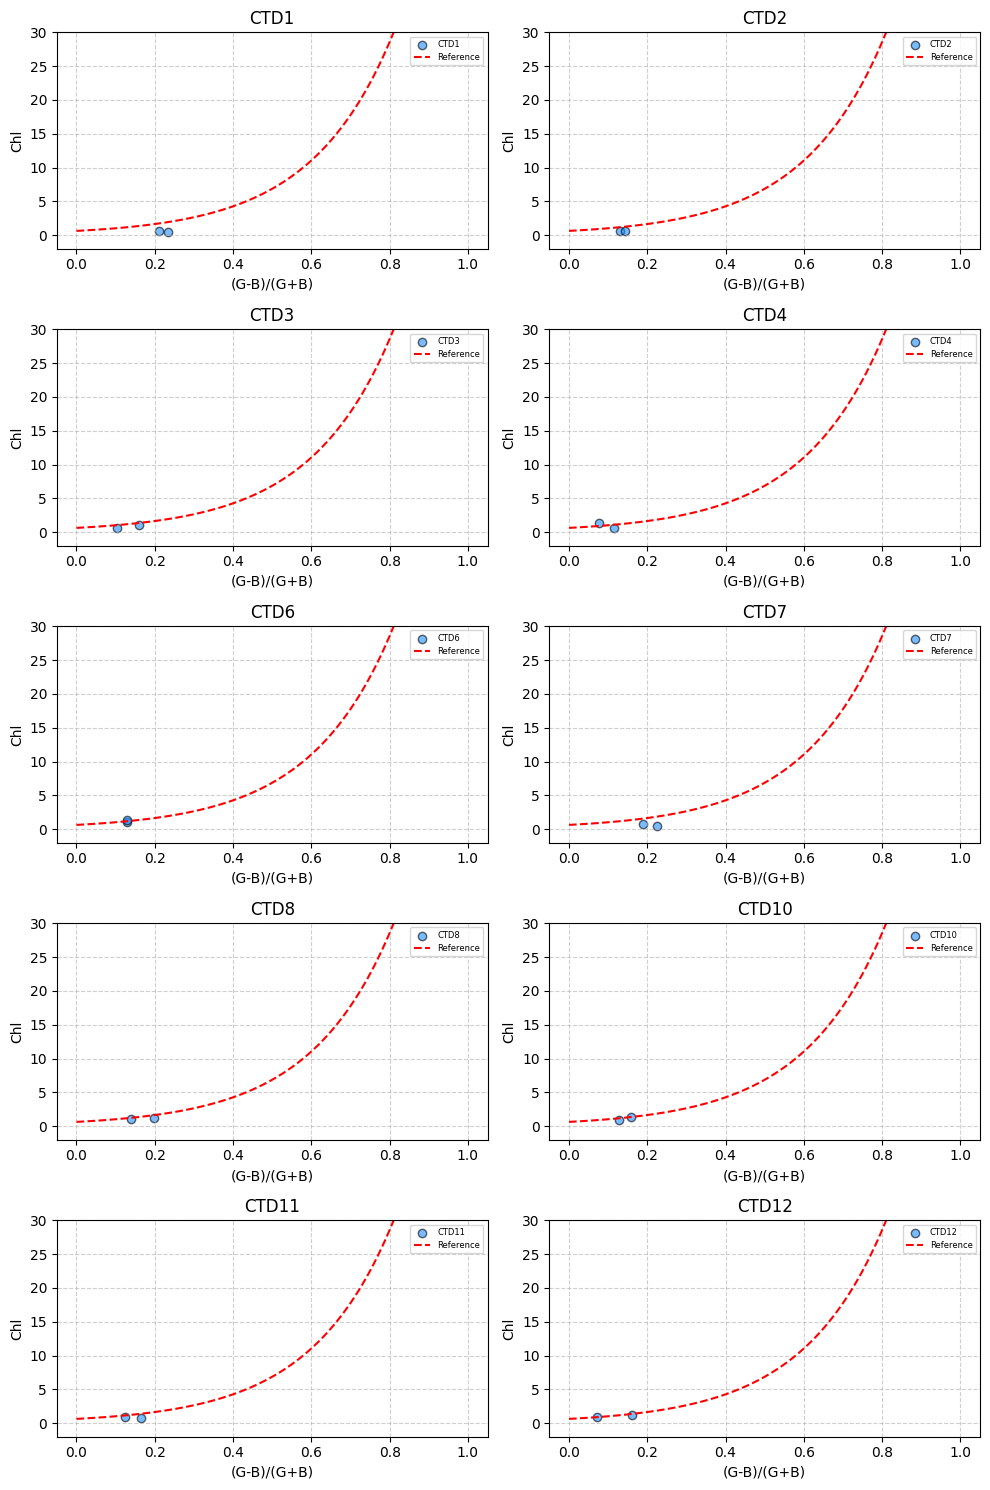

In [12]:
buoys = df["Buoy"].unique()

# Create subplots dynamically
fig, axes = plt.subplots(nrows=len(buoys)//2 + len(buoys)%2, ncols=2, figsize=(10, len(buoys)*1.5))
axes = axes.flatten()  # Flatten in case of multiple rows

# Reference curve for plotting
x_ref = np.linspace(0, 1, 101)
y_ref = 0.6386 * np.exp(4.7513 * x_ref)

for idx, buoy in enumerate(buoys):
    ax = axes[idx]
    
    # Filter data for the buoy
    df_buoy = df[df["Buoy"] == buoy]
    
    # Scatter plot
    ax.scatter(df_buoy["norm_dif_green_blue"], df_buoy["Chl"], color="dodgerblue", alpha=0.6, edgecolor="k", label=f"{buoy}")
    
    # Reference curve
    ax.plot(x_ref, y_ref, color="red", linestyle="--", label="Reference")
    
    ax.set_xlabel("(G-B)/(G+B)")
    ax.set_ylabel("Chl")
    ax.set_title(f"{buoy}")
    ax.grid(True, linestyle="--", alpha=0.6)
    ax.set_ylim(-2, 30)
    ax.legend(fontsize=6)

# If there are empty axes (because number of buoys is odd), hide them
for i in range(len(buoys), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

### 2. tfg

In [14]:
df = pd.read_csv("saved_files/df_boyas_tiffs_c2x_test.csv")
df = df.drop(columns=["Latitude", "Longitude"])
df = df.rename(columns={"Band_1" : "UltraBlue", "Band_2" : "Blue", "Band_3" : "Green", "Band_4" : "Red", "Band_5" : "NIR1", "Band_6" : "NIR2", "Band_7" : "NIR3"})
df['Date'] = pd.to_datetime(df['Date'])
dates = df["Date"].copy()
df = df.drop(columns=["Date"]) 

In [208]:
filter_dates = [
    "28/10/2016", "20/06/2018", "07/11/2018", "14/08/2019",
    "30/06/2017", "10/07/2018", "12/03/2019", "18/09/2019",
    "20/02/2018", "29/08/2018", "25/06/2019", "03/10/2019",
    "07/03/2018", "03/10/2018"
]

filter_dates_dt = pd.to_datetime(filter_dates, dayfirst=True)

# Filter the DataFrame
df = df[df["Date"].isin(filter_dates_dt)]

In [15]:
def norm_sum(band1, band2, band3):
    index = (band1 + band3)/(band1 + band2)
    return index

def add_index(data):
    df["norm_sum"] = norm_sum(data["Green"], data["Red"], data["NIR1"])
    df["Chl_pred"] = 124.94*norm_sum(data["Green"], data["Red"], data["NIR1"])-115.35
    
add_index(df)


In [16]:
rmse = np.sqrt(mean_squared_error(df["Chl"], df["Chl_pred"]))
print('RMSE: %.3f' % rmse)
r2 = r2_score(df["Chl"], df["Chl_pred"])
print('R squared: %.3f' % r2)
nrmse = rmse / np.mean(df["Chl"]) * 100
print(f"NRMSE: {nrmse:.1f}%")


RMSE: 1.959
R squared: -43.165
NRMSE: 217.7%


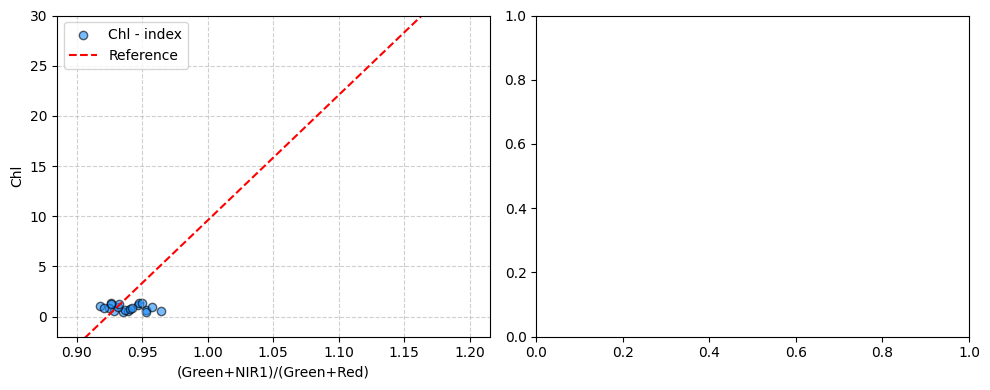

In [17]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))

# Train plot
axes[0].scatter(df["norm_sum"], df["Chl"], color="dodgerblue", alpha=0.6, edgecolor="k", label="Chl - index")
x_ref = np.linspace(0.9, 1.2, 101)
y_ref = 124.94*x_ref-115.35
axes[0].plot(x_ref, y_ref, color="red", linestyle="--", label="Reference")
axes[0].set_xlabel("(Green+NIR1)/(Green+Red)")
axes[0].set_ylabel("Chl")
axes[0].legend()
axes[0].grid(True, linestyle="--", alpha=0.6)
axes[0].set_ylim(-2,30)

plt.tight_layout()
plt.show()

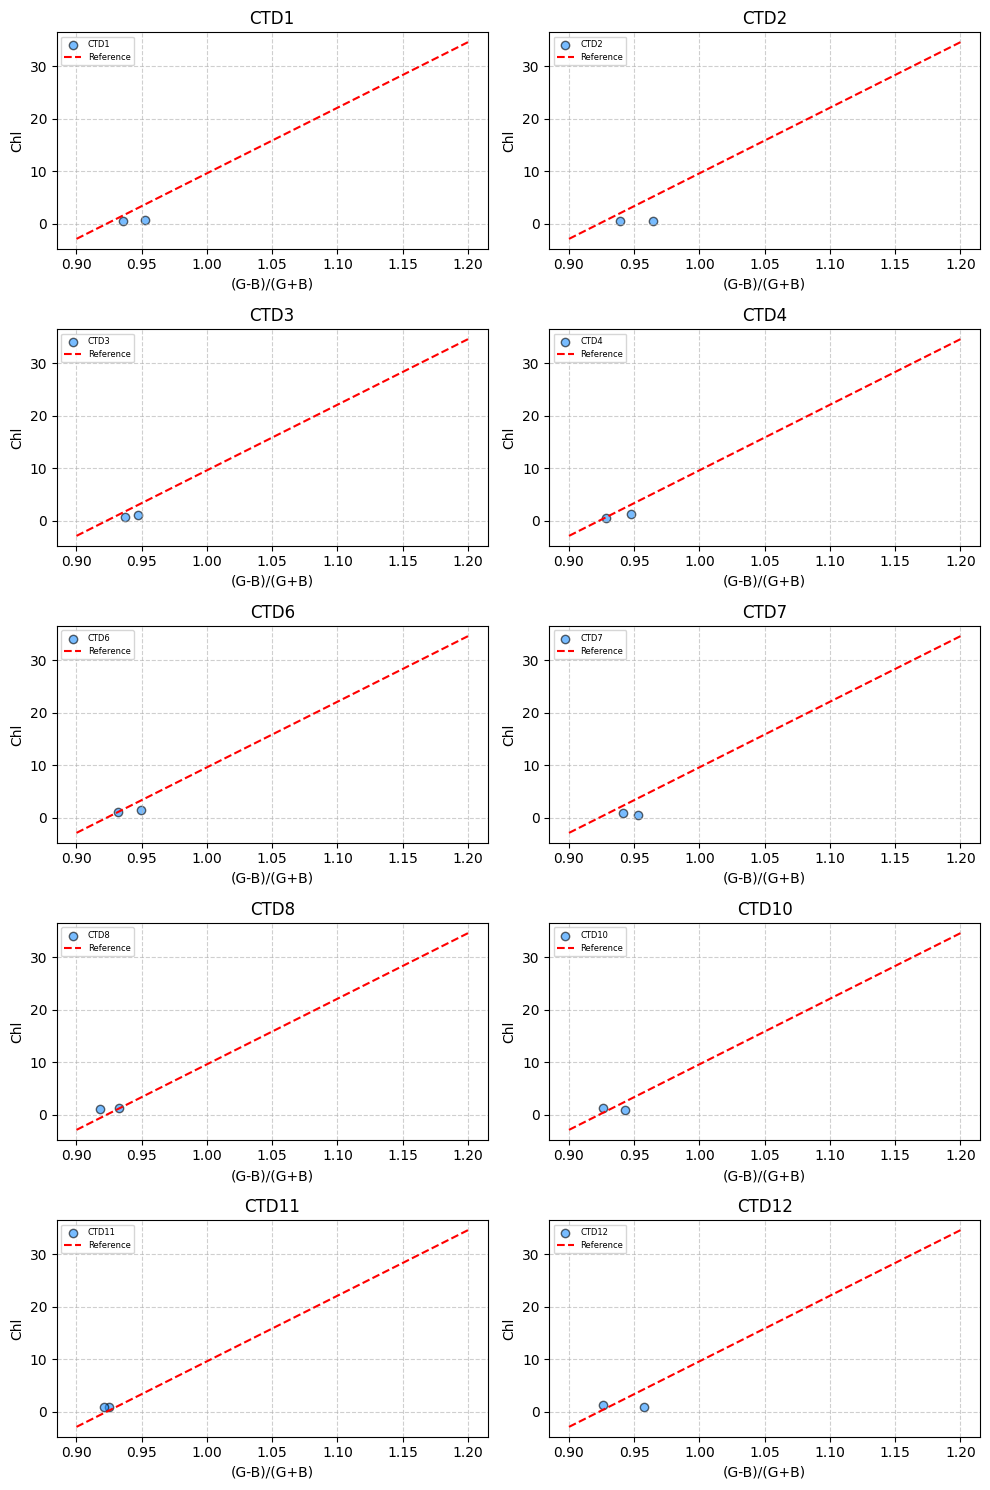

In [18]:
buoys = df["Buoy"].unique()

# Create subplots dynamically
fig, axes = plt.subplots(nrows=len(buoys)//2 + len(buoys)%2, ncols=2, figsize=(10, len(buoys)*1.5))
axes = axes.flatten()  # Flatten in case of multiple rows

# Reference curve for plotting
x_ref = np.linspace(0.9, 1.2, 101)
y_ref = 124.94*x_ref-115.35

for idx, buoy in enumerate(buoys):
    ax = axes[idx]
    
    # Filter data for the buoy
    df_buoy = df[df["Buoy"] == buoy]
    
    # Scatter plot
    ax.scatter(df_buoy["norm_sum"], df_buoy["Chl"], color="dodgerblue", alpha=0.6, edgecolor="k", label=f"{buoy}")
    
    # Reference curve
    ax.plot(x_ref, y_ref, color="red", linestyle="--", label="Reference")
    
    ax.set_xlabel("(G-B)/(G+B)")
    ax.set_ylabel("Chl")
    ax.set_title(f"{buoy}")
    ax.grid(True, linestyle="--", alpha=0.6)
    #ax.set_ylim(-2, 30)
    ax.legend(fontsize=6)

# If there are empty axes (because number of buoys is odd), hide them
for i in range(len(buoys), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

In [218]:
from sklearn.linear_model import LinearRegression

X = df[["norm_sum"]]  # or whatever index you're testing
y = df["Chl"]

model = LinearRegression().fit(X, y)
df["Chl_fit"] = model.predict(X)

r2 = r2_score(y, df["Chl_fit"])
rmse = np.sqrt(mean_squared_error(y, df["Chl_fit"]))
nrmse = rmse / np.mean(y) * 100
print('RMSE: %.3f' % rmse)
print('R squared: %.3f' % r2)
print(f"NRMSE: {nrmse:.1f}%")

RMSE: 3.552
R squared: 0.074
NRMSE: 113.9%
